In [32]:
import torch
import torch.nn as nn
import torch.optim as op
import torch.nn.functional as f
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [33]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307, ), (0.3081,))
])

train_dataset= datasets.MNIST(root = './data', train=True, download=True, transform=transforms)
test_dataset= datasets.MNIST(root = './data', train=False, download=True, transform=transforms)

train_loader= DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader= DataLoader(test_dataset, batch_size=1000, shuffle=False)

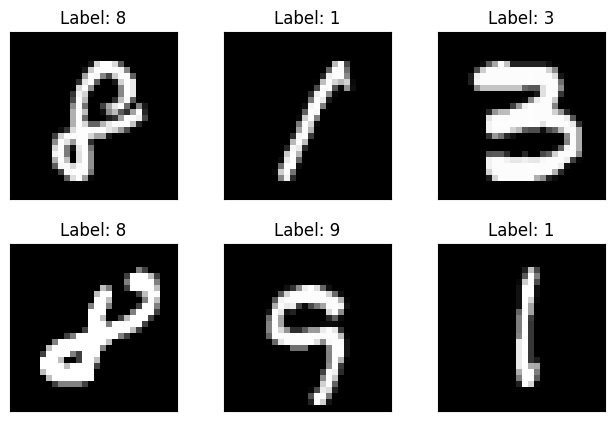

In [34]:
example = enumerate(train_loader)

batch_idx, (example_data, example_tragets) = next(example)

fig = plt.figure()

for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Label: {}".format(example_tragets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()



In [35]:
class CNN(nn.Module):

  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
    self.dropout1 = nn.Dropout2d(0.25)
    self.dropout2 = nn.Dropout2d(0.5)
    self.fc1 = nn.Linear(9216, 128)
    self.fc2 = nn.Linear(128, 10)

  def forward(self,x):
    x= f.relu(self.conv1(x))
    x= f.relu(self.conv2(x))
    x= f.max_pool2d(x,2)
    x= self.dropout1(x)
    x= torch.flatten(x,1)
    x = f.relu(self.fc1(x))
    x= self.dropout2(x)
    x=self.fc2(x)
    return f.log_softmax(x, dim=1)



In [36]:
# !pip install torchsummary

In [37]:
from torchsummary import summary
device = torch.device('cude' if torch.cuda.is_available() else 'cpu')
model = CNN().to(device)
optimizer=op.Adam(model.parameters(), lr=0.001)
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
            Conv2d-2           [-1, 64, 24, 24]          18,496
         Dropout2d-3           [-1, 64, 12, 12]               0
            Linear-4                  [-1, 128]       1,179,776
         Dropout2d-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 1,199,882
Trainable params: 1,199,882
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.52
Params size (MB): 4.58
Estimated Total Size (MB): 5.10
----------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


In [38]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = f.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}]  Loss: {loss.item():.6f}")

In [39]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            test_loss += f.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")



In [40]:
for epoch in range(1,6):
  train(model, device, train_loader, optimizer, epoch)
  test(model, device, test_loader)


Train Epoch: 1 [0/60000]  Loss: 2.317499
Train Epoch: 1 [6400/60000]  Loss: 0.236470
Train Epoch: 1 [12800/60000]  Loss: 0.281222
Train Epoch: 1 [19200/60000]  Loss: 0.083269
Train Epoch: 1 [25600/60000]  Loss: 0.127593
Train Epoch: 1 [32000/60000]  Loss: 0.229515
Train Epoch: 1 [38400/60000]  Loss: 0.173492
Train Epoch: 1 [44800/60000]  Loss: 0.155418
Train Epoch: 1 [51200/60000]  Loss: 0.012483
Train Epoch: 1 [57600/60000]  Loss: 0.015082

Test set: Average loss: 0.0441, Accuracy: 9843/10000 (98.43%)

Train Epoch: 2 [0/60000]  Loss: 0.079729
Train Epoch: 2 [6400/60000]  Loss: 0.112873
Train Epoch: 2 [12800/60000]  Loss: 0.101519
Train Epoch: 2 [19200/60000]  Loss: 0.050811
Train Epoch: 2 [25600/60000]  Loss: 0.155851
Train Epoch: 2 [32000/60000]  Loss: 0.127485
Train Epoch: 2 [38400/60000]  Loss: 0.090252
Train Epoch: 2 [44800/60000]  Loss: 0.039046
Train Epoch: 2 [51200/60000]  Loss: 0.041411
Train Epoch: 2 [57600/60000]  Loss: 0.282635

Test set: Average loss: 0.0396, Accuracy: 987

In [41]:
model_path= 'mnist_cnn.path'
torch.save(model.state_dict(), model_path)
print(f"Model Saved to {model_path}")

Model Saved to mnist_cnn.path


In [42]:
loaded_model =CNN().to(device)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()
print("Model loaded successfully.")

Model loaded successfully.


In [43]:
# 10. Make prediction with loaded model
def predict(model, device, data_loader, num_samples=6):
    model.eval()
    data_iter = iter(data_loader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)
    output = model(images)
    preds = output.argmax(dim=1)

    # Visualize predictions
    fig = plt.figure()
    for i in range(num_samples):
        plt.subplot(2, 3, i + 1)
        plt.tight_layout()
        plt.imshow(images[i][0].cpu(), cmap='gray', interpolation='none')
        plt.title(f"Pred: {preds[i].item()}, Label: {labels[i].item()}")
        plt.xticks([])
        plt.yticks([])
    plt.show()

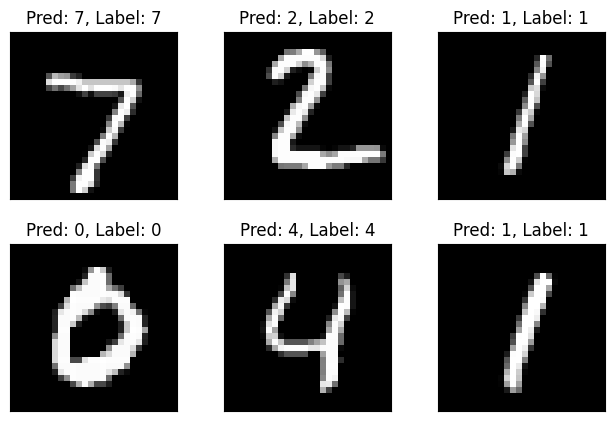

In [44]:
# Run prediction
predict(loaded_model, device, test_loader)